<a href="https://colab.research.google.com/github/HenryZumaeta/py4dl_EPC2026/blob/main/C03_Script01_Analisis_RedNeuronal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
# modulos
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Redes Neuronales: Keras
from  keras.models import Sequential
from keras.layers import Dense

# Descargamos el dataset de kaggle
!kaggle datasets download robintux/salud-mental-agotamiento-estudiantil

# Descomprimirlo
!unzip salud-mental-agotamiento-estudiantil.zip

# Cargar en memoria
df = pd.read_csv("Salud_mental_agotamiento_estudiantil.csv")
df = df.drop("Unnamed: 0", axis = 1)

df = df[df.dropout_risk >= 0.1].reset_index(drop = True)
# df = df.sample(frac= 0.1).reset_index(drop = True)

X = df.iloc[:, :-1]
y = df.dropout_risk

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25)

# A la primera arquitectura cambiemosle la funcion de activacion de la capa de salida
# Instanciamos la clase Sequential
ModelBase = Sequential()

# Agregamos capas ocultas
# La primera capa oculta posee la informacion de la capa de entrada, es
# decir de las variables independientes
ModelBase.add(Dense(
    units = 10,
    activation = "relu",
    input_dim = X.shape[1],
    name = "Primera_capa_oculta"
))

# Agreguemos 7 capas ocultas
ModelBase.add(Dense(
    units = 16,
    activation = "elu",
    name = "Segunda_capa_oculta"
))

ModelBase.add(Dense(
    units = 24,
    activation = "selu",
    name = "Tercera_capa_oculta"
))

ModelBase.add(Dense(
    units = 15,
    activation = "relu",
    name = "Cuarta_capa_oculta"
))

ModelBase.add(Dense(
    units = 14,
    activation = "tanh",
    name = "Quinta_capa_oculta"
))

ModelBase.add(Dense(
    units = 15,
    activation = "relu",
    name = "Sexta_capa_oculta"
))

ModelBase.add(Dense(
    units = 5,
    activation = "relu",
    name = "Septima_capa_oculta"
))

ModelBase.add(Dense(
    units = 3,
    activation = "exponential",
    name = "octava_capa_oculta"
))

# Capa de Salida
ModelBase.add(Dense(
    units  = 1 ,
    activation = "linear",
    name = "Capa_de_Salida"
))

# Compilamos el modelo
ModelBase.compile(
    loss = "mean_absolute_error",
    optimizer = "adam",
    metrics = ["mean_absolute_percentage_error"]
)

# Procedimiento de ajuste
HistoriaAjusteModelBase2 = ModelBase.fit(X_train, y_train,
                                         epochs = 10,
                                         batch_size = 128)


# Calculamos pronosticos
y_forecast_base2 = ModelBase.predict(X_test)

# Indicador de calidad
mape2_base = metrics.mean_absolute_percentage_error(y_test, y_forecast_base2)
mape2_base

Dataset URL: https://www.kaggle.com/datasets/robintux/salud-mental-agotamiento-estudiantil
License(s): apache-2.0
salud-mental-agotamiento-estudiantil.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  salud-mental-agotamiento-estudiantil.zip
replace Salud_mental_agotamiento_estudiantil.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Salud_mental_agotamiento_estudiantil.csv  


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
4194/4194 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.6867 - mean_absolute_percentage_error: 75.9672
Epoch 2/10
4194/4194 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - loss: 0.6668 - mean_absolute_percentage_error: 73.1137
Epoch 3/10
4194/4194 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.6663 - mean_absolute_percentage_error: 73.0167
Epoch 4/10
4194/4194 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - loss: 0.6655 - mean_absolute_percentage_error: 72.9621
Epoch 5/10
4194/4194 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.6650 - mean_absolute_percentage_error: 72.9157
Epoch 6/10
4194/4194 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 0.6646 - mean_absolute_percentage_error: 72.8506
Epoch 7/10
4194/4194 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.6645 - mean_absolute_percentage_error: 72.8225
Epoch 8/10
4194/4194 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 0.6641 - mean_absolute_percentage_error: 72.8567
Epoch 9/10
4194/4194 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.6639 - mean_absolute_percentage_error: 

0.7084637164366269

In [42]:
# Tipo de dato
type(ModelBase)

keras.src.models.sequential.Sequential

In [43]:
# LIsta de metodos y atributos que se puede aplicar a un dato instancia de la clase
# Sequential : Funcion dir
dir(ModelBase)

['__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_trackable_child',
 '_add_variable_with_custom_getter',
 '_aggregate_additional_loss',
 '_allow_non_tensor_positional_args',
 '_api_export_path',
 '_api_export_symbol_id',
 '_assert_compile_called',
 '_assert_input_compatibility',
 '_assign_variable_values',
 '_auto_config',
 '_autoconvert_optionals',
 '_build_at_init',
 '_build_by_run_for_kwargs',
 '_build_by_run_for_single_pos_arg',
 '_build_shapes_dict',
 '_call_context_args',
 '_call_has_context_arg',
 '_call_has_mask_arg',
 '_call_has_training_arg',
 '_call_signature',
 '_called',
 '_check_load_own_variables',
 '

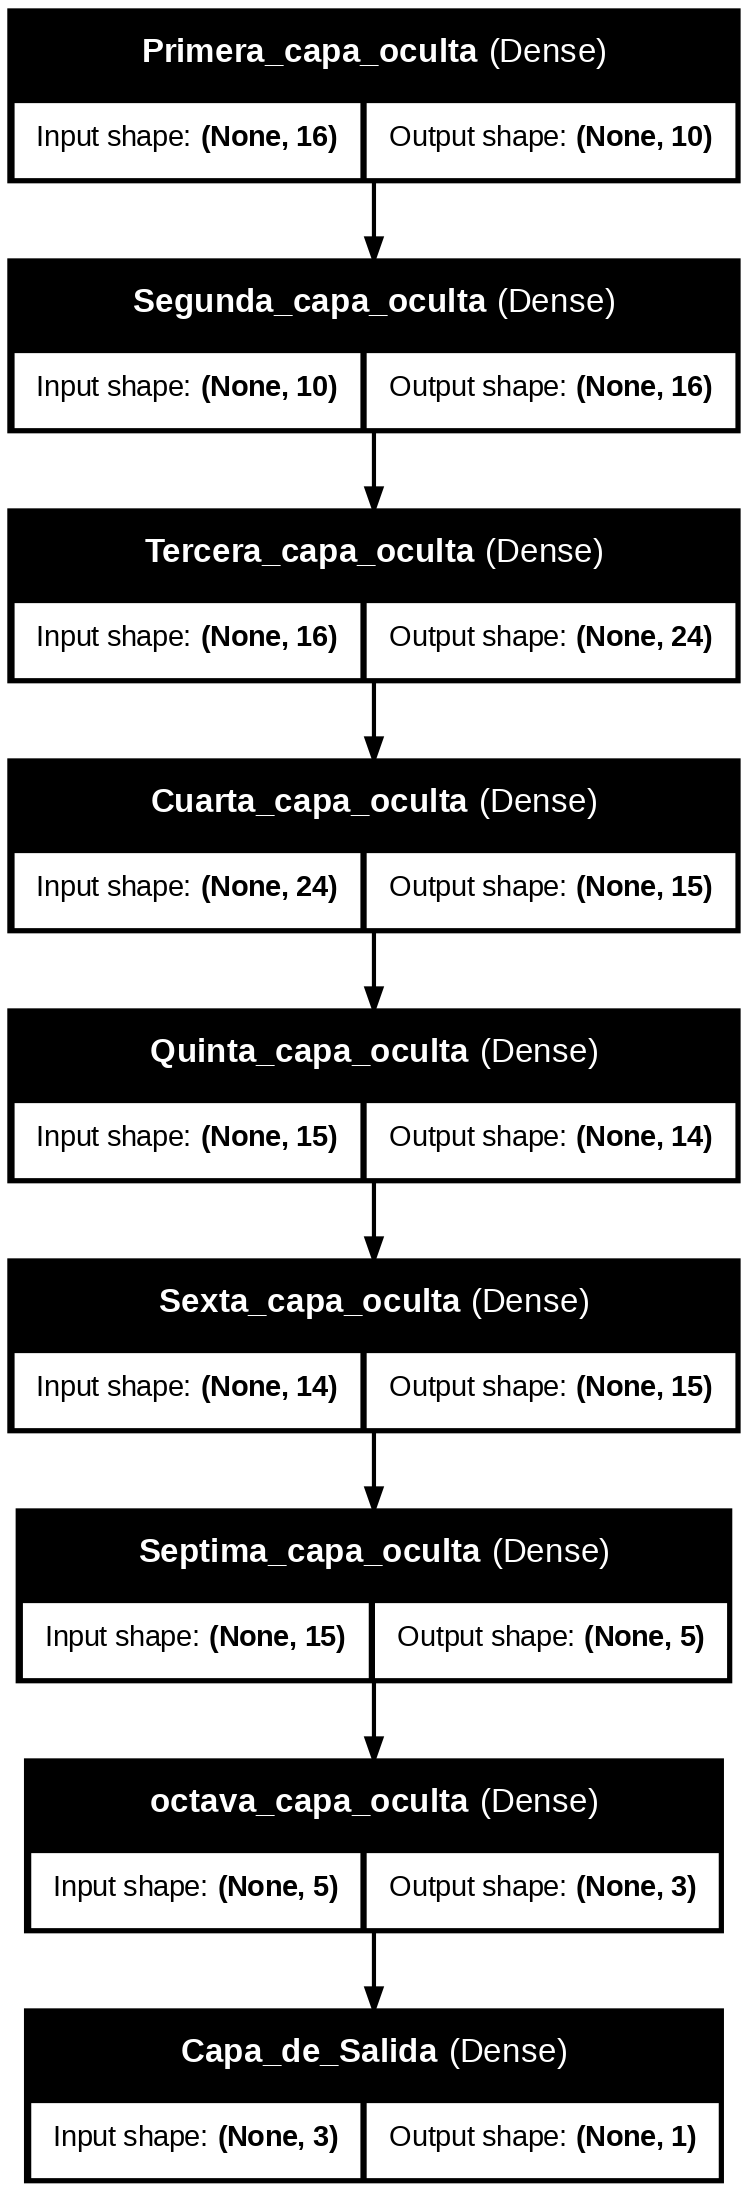

In [44]:
# Podemos visualizar el objeto ModelBase
from keras.utils import plot_model

plot_model(ModelBase,
           show_shapes=True,
           show_layer_names=True,
           to_file = "mi_primer_perceptron.png",
           dpi = 150)

In [45]:
# Almacenamos en disco duro nuestro modelo
ModelBase.save("modelo_base_sesion2.keras")

# Para poder visualizar el modelo ajustado : https://netron.app/

In [46]:
ModelBase.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Primera_capa_oculta (Dense)     │ (None, 10)             │           170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Segunda_capa_oculta (Dense)     │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Tercera_capa_oculta (Dense)     │ (None, 24)             │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Cuarta_capa_oculta (Dense)      │ (None, 15)             │           375 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Quinta_capa_oculta (Dense)      │ (None, 14)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sexta_capa_oculta (Dense)       │ (None, 15)             │           225 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Septima_capa_oculta (Dense)     │ (None, 5)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ octava_capa_oculta (Dense)      │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_de_Salida (Dense)          │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,042 (19.70 KB)

 Trainable params: 1,680 (6.56 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,362 (13.14 KB)

In [47]:
# Experimento
# Ajustar el modelo ModelBase con diferentes subconjuntos de entrenamiento

def built_mape():

    # A la primera arquitectura cambiemosle la funcion de activacion de la capa de salida
    # Instanciamos la clase Sequential
    ModelBase = Sequential()

    # Agregamos capas ocultas
    # La primera capa oculta posee la informacion de la capa de entrada, es
    # decir de las variables independientes
    ModelBase.add(Dense(
        units = 10,
        activation = "relu",
        input_dim = X.shape[1],
        name = "Primera_capa_oculta"
    ))

    # Agreguemos 7 capas ocultas
    ModelBase.add(Dense(
        units = 16,
        activation = "elu",
        name = "Segunda_capa_oculta"
    ))

    ModelBase.add(Dense(
        units = 24,
        activation = "selu",
        name = "Tercera_capa_oculta"
    ))

    ModelBase.add(Dense(
        units = 15,
        activation = "relu",
        name = "Cuarta_capa_oculta"
    ))

    ModelBase.add(Dense(
        units = 14,
        activation = "tanh",
        name = "Quinta_capa_oculta"
    ))

    ModelBase.add(Dense(
        units = 15,
        activation = "relu",
        name = "Sexta_capa_oculta"
    ))

    ModelBase.add(Dense(
        units = 5,
        activation = "relu",
        name = "Septima_capa_oculta"
    ))

    ModelBase.add(Dense(
        units = 3,
        activation = "exponential",
        name = "octava_capa_oculta"
    ))

    # Capa de Salida
    ModelBase.add(Dense(
        units  = 1 ,
        activation = "linear",
        name = "Capa_de_Salida"
    ))

    # Compilamos el modelo
    ModelBase.compile(
        loss = "mean_absolute_error",
        optimizer = "adam",
        metrics = ["mean_absolute_percentage_error"]
    )

    # Procedimiento de ajuste
    HistoriaAjusteModelBase2 = ModelBase.fit(X_train, y_train,
                                            epochs = 10,
                                            batch_size = 128,
                                            #  Silenciar la informacion de cada epoca
                                            verbose = 0 )


    # Calculamos pronosticos
    y_forecast_base2 = ModelBase.predict(X_test)

    # Indicador de calidad
    mape2_base = metrics.mean_absolute_percentage_error(y_test, y_forecast_base2)
    return mape2_base

In [48]:
# Definamos un numero de experimentos

# Lista para almacenar los mape obtenidos en cada experimento
lista_mape = []

# LO adecuado es realizar un mayor numero de experimentos (20-40)
num_exp = 5

for exp in range(num_exp):
    ts = 0.25
    X_train, X_test, y_train , y_test = train_test_split(X, y, test_size= ts)
    mape_exp = built_mape()
    # Agregar Funcionalidad : Guardar la informacion con la que se ajusto en entrenamiento (X_train, y_train)
    # y tambien la informacion con la que se calculo el indicador de calidad (X_test, y_test)
    lista_mape.append(mape_exp)
# Lista para almacenar los mape obtenidos en cada experimento
lista_mape = []

num_exp = 5
for exp in range(num_exp):
    ts = 0.25
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= ts)
    mape_exp = built_mape()
    lista_mape.append(mape_exp)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5592/5592 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5592/5592 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

5592/5592 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5592/5592 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5592/5592 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


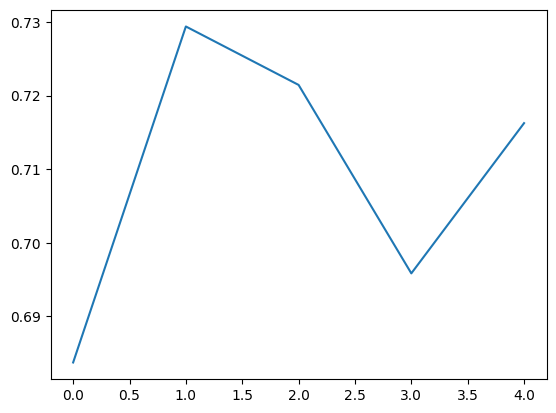

In [49]:
plt.plot(lista_mape)

In [50]:
# Extraccion de pesos y sesgos

# Accedamos a las capas
ModelBase.layers
# Devuelve una lista con cada una de las capas

[<Dense name=Primera_capa_oculta, built=True>,
 <Dense name=Segunda_capa_oculta, built=True>,
 <Dense name=Tercera_capa_oculta, built=True>,
 <Dense name=Cuarta_capa_oculta, built=True>,
 <Dense name=Quinta_capa_oculta, built=True>,
 <Dense name=Sexta_capa_oculta, built=True>,
 <Dense name=Septima_capa_oculta, built=True>,
 <Dense name=octava_capa_oculta, built=True>,
 <Dense name=Capa_de_Salida, built=True>]

In [51]:
# Seleccionemos una de estas capas
# INstancia de la clase Dense
# type(ModelBase.layers[3])

# Listar los metodos/atributos que se puede aplicar a un objeto instancia de la clase Dense
# dir(ModelBase.layers[3])

ModelBase.layers[3].get_weights()

[array([[ 0.4524114 ,  0.00383334,  0.40695226,  0.13278581,  0.4170102 ,
         -0.20372467,  0.50306404,  0.37863442, -0.315655  , -0.1741485 ,
         -0.14412798,  0.24743943,  0.43994465,  0.21707146, -0.05044886],
        [-0.18391587, -0.29123238,  0.25331473,  0.40973487, -0.43464145,
         -0.03112205,  0.4798698 , -0.46118197,  0.25362295, -0.08730102,
          0.34465104,  0.07160781, -0.1127494 ,  0.21615101,  0.44630677],
        [-0.24663703, -0.10871329, -0.2497058 , -0.19021158, -0.12972054,
         -0.285239  , -0.1546214 , -0.23453167, -0.24984547,  0.24579766,
         -0.00082017, -0.2334197 ,  0.18514769,  0.24354692,  0.30075225],
        [ 0.00249065,  0.01020635,  0.07542704, -0.00435637, -0.2935799 ,
          0.23338456, -0.18880971,  0.11043058,  0.43158215,  0.10596933,
          0.44124466,  0.1560293 ,  0.1353911 , -0.05230894, -0.05600614],
        [-0.11078832, -0.36823872,  0.07408769, -0.09872656,  0.3186471 ,
         -0.38418254,  0.21572699,

In [52]:
# Implementemos una funcion que permita obtener la matriz de  pesos
# y el vector de sesgos de mi modelo
def extract_layer_weights(model):
    """
    Extrae pesos y sesgos de cada capa Dense del modelo
    """
    layers_info = []
    # Buena practica : Acceder tanto a las instancia de la clase Dense
    # como al lugar que ocupa en la lista que devuelve el atributo layers
    for i,  layer in enumerate(model.layers):
        # Filtramos solo a las instancias de la clase Dense
        if isinstance(layer, Dense):
            weights , biases = layer.get_weights()
            layers_info.append({
                "name": layer.name,
                "index" : i,
                "weights" : weights,
                "biases": biases,
                "shape" : weights.shape
            })

    # Output de la funcion
    return layers_info

# Extracccion de la informacion
layers_data = extract_layer_weights(ModelBase)


In [53]:
layers_data

[{'name': 'Primera_capa_oculta',
  'index': 0,
  'weights': array([[ 0.31405336,  0.45636263, -0.31536373, -0.22192326, -0.15108603,
          -0.37306163, -0.09550619, -0.22269252,  0.45928848, -0.06815055],
         [-0.00976153, -0.28958422,  0.07411204, -0.43218216,  0.29104462,
           0.20960303, -0.46681157,  0.37876165,  0.27827567,  0.09622639],
         [-0.06184051,  0.00592167, -0.12410375,  0.1342811 ,  0.04993448,
           0.04445298, -0.18331835, -0.24791983, -0.36631724, -0.46329403],
         [-0.14855224, -0.4335657 ,  0.31609038, -0.29647148,  0.10594917,
           0.22922182, -0.26098847, -0.06779069, -0.3916734 , -0.13199502],
         [ 0.3536328 ,  0.33969802,  0.23661214,  0.18670553, -0.17159334,
          -0.46419194, -0.21941602, -0.08829724, -0.32882833,  0.20053923],
         [-0.44304454, -0.4831945 , -0.26688188, -0.14466667,  0.19731288,
           0.19439845, -0.3365546 ,  0.40177366,  0.11532295, -0.18181372],
         [ 0.285501  , -0.18953109, 

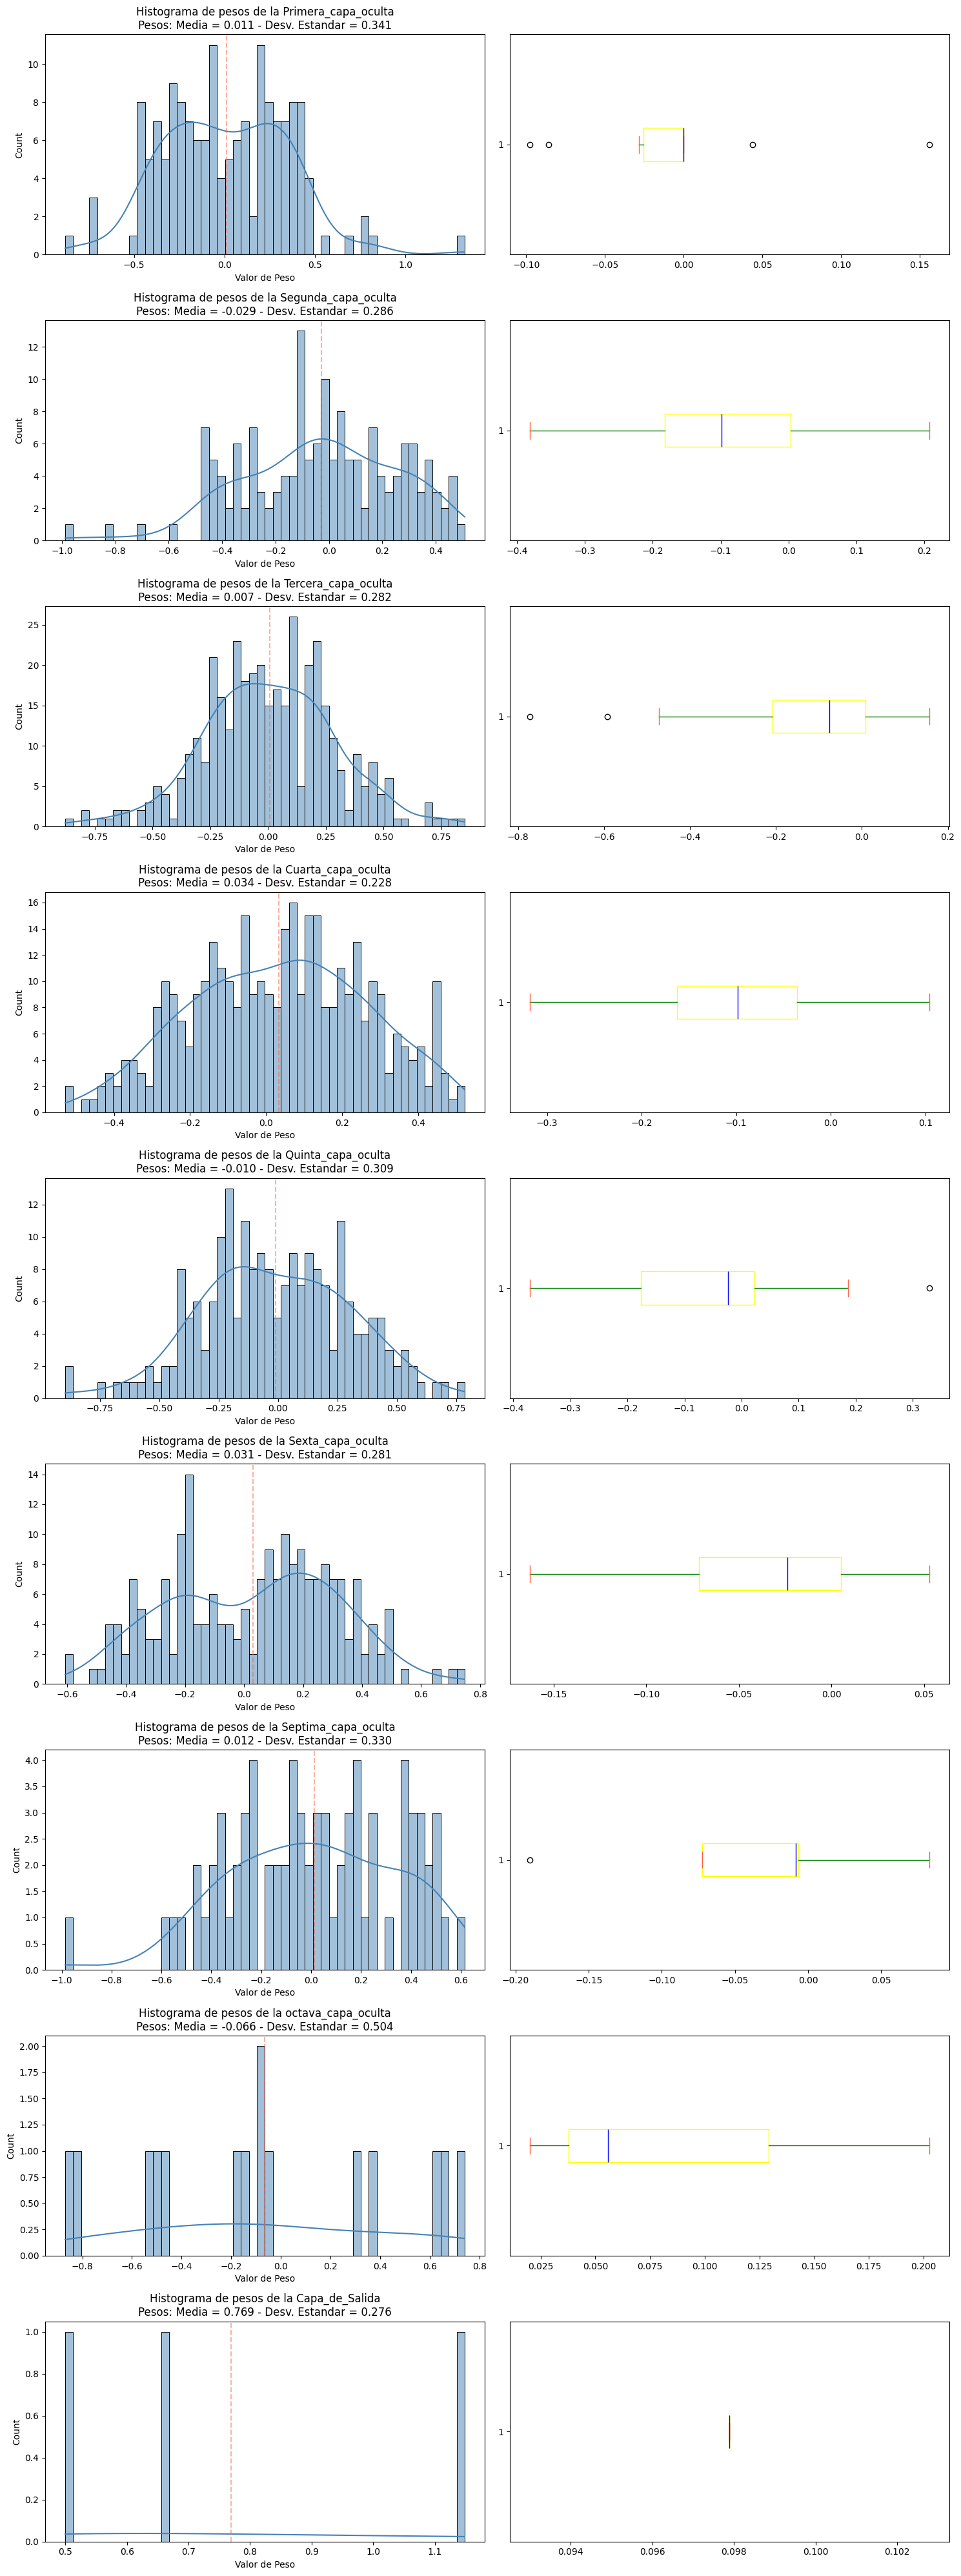

In [54]:
# Histograma de la matriz de peso y boxplot del vector de sesgos
def plot_weight_distribution(layers_data, figsize = (15,40)):
    """
    Histogramas con KDE de la distribución de pesos por cada
    Boxplot del vector de sesgos por capa
    """

    fig, axes = plt.subplots(nrows = len(layers_data),
                             ncols = 2,
                             figsize = figsize)
    for idx, layer in enumerate(layers_data):
        # Recuperemos las matrices de pesos y los vectores de sesgos
        weigths = layer["weights"].flatten() # Transformamos la matriz de pesos en un vector
        biases = layer["biases"]

        # Histograma + KDE de los pesos
        sns.histplot(weigths, bins = 50, kde = True, ax = axes[idx,0], color = "steelblue")
        axes[idx,0].axvline(weigths.mean(), color = "tomato", linestyle = "--", alpha = 0.5)
        axes[idx,0].set_title(f"Histograma de pesos de la {layer['name']}\nPesos: Media = {weigths.mean():.3f} - Desv. Estandar = {weigths.std():.3f}")
        axes[idx,0].set_xlabel("Valor de Peso")

        # Boxplot de los sesgos
        # Con Seaborn
        # sns.boxplot(biases, ax = axes[idx,1], color = "steelblue")
        # axes[idx,1].axvline(biases.mean(), color = "tomato", linestyle = "--", alpha = 0.5)

        # Con Matplotlib
        axes[idx, 1].boxplot(biases, vert = False,
                              boxprops = {"color": "yellow"},
                              medianprops = {"color": "blue"},
                              whiskerprops = {"color": "green"},
                              capprops = {"color": "tomato"},
                              flierprops = {"marker": "o", "color": "tomato"}
                              )



    plt.tight_layout()
    return fig

# Ejemplo de uso
fig_weights = plot_weight_distribution(layers_data)
plt.show()

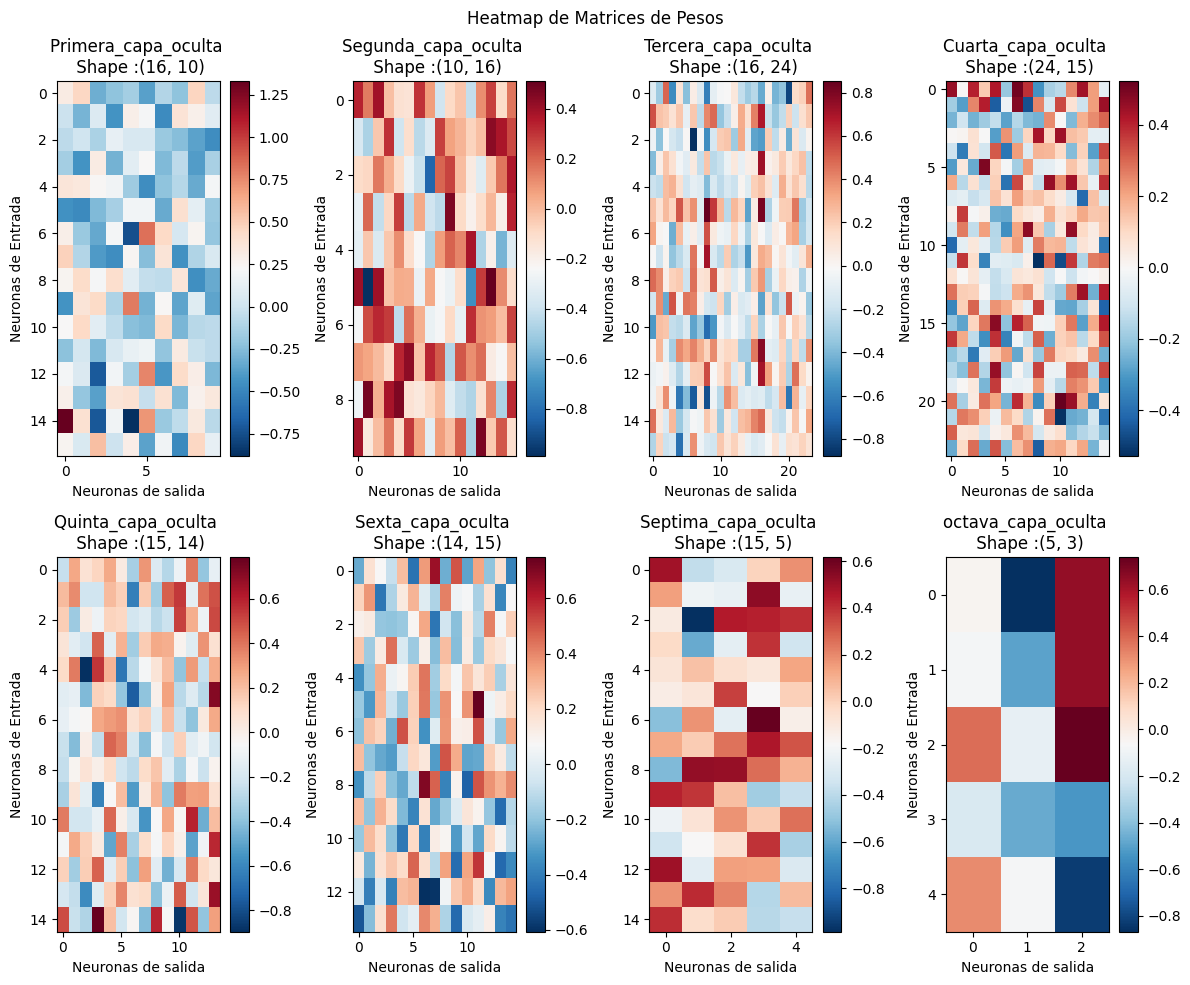

In [55]:
# Heatmaps de las matrices de pesos
def visualize_weight_heatmaps(model, figsize = (12, 10), max_layers = 8):
    """
    Funcion para mostrar las matrices de pesos de las primeras capas de un perceptron
    """
    dense_layers = [layer for layer in model.layers if isinstance(layer, Dense)][:max_layers]
    n_layers = len(dense_layers)

    fig, axes = plt.subplots(2, (n_layers+1)//2, figsize =figsize)
    axes = axes.flatten()

    for i , layer in enumerate(dense_layers):
        weights = layer.get_weights()[0]

        # Aca puede aparecer un problema : El numero de neuronas de dos capas consecutivas
        # pueden ser muy grandes => Podemos muestrear
        if weights.shape[0] > 50 or weights.shape[1]> 50:
            sample_idx = np.random.choice(weights.shape[0], min(50, weights.shape[0]) , replace = False)
            weights_sample = weights[sample_idx, :]
        else:
            weights_sample = weights

        # Heatmap : Mostramos las componentes de weights_sample
        im = axes[i].imshow(weights_sample, cmap = "RdBu_r", aspect = "auto", interpolation = "nearest")
        axes[i].set_title(f"{layer.name} \n Shape :{weights_sample.shape}")
        axes[i].set_xlabel("Neuronas de salida")
        axes[i].set_ylabel("Neuronas de Entrada")
        plt.colorbar(im, ax = axes[i])
        axes[i].grid(False)

    # Titulo Superior
    plt.suptitle("Heatmap de Matrices de Pesos")
    plt.tight_layout()
    return fig

# Ejemplo de uso
fig = visualize_weight_heatmaps(ModelBase)
plt.show()
